In [1]:
import os
os.chdir(r'C:\Users\user\Documents\supply_chain_analysis')

In [2]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.1 MB 8.9 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/12.1 MB 9.1 MB/s eta 0:00:01
   ------------------ --------------------- 5.5/12.1 MB 9.2 MB/s eta 0:00:01
   ------------------------ --------------- 7.3/12.1 MB 9.2 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/12.1 MB 9.2 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.1 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 8.9 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ----------------------------------- ---- 1.3/1.5 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.8 MB/s  0:00:00

   -------- ------------------------------- 1/5 [importlib_resources]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- -----------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
print("All libraries loaded!")

All libraries loaded!


In [4]:
df = pd.read_csv('data/cleaned/supply_chain_cleaned.csv', encoding='latin-1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
print("Shape:", df.shape)
print("Date range:", df['order date (DateOrders)'].min(), "to", df['order date (DateOrders)'].max())

Shape: (180519, 51)
Date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00


In [5]:
daily_orders = df.groupby('order date (DateOrders)')['Order Id'].count().reset_index()
daily_orders.columns = ['ds', 'y']
daily_orders = daily_orders.sort_values('ds')

print("Daily orders prepared:")
print(daily_orders.head())
print(f"\nTotal days: {len(daily_orders)}")
print(f"Avg daily orders: {daily_orders['y'].mean():.0f}")

Daily orders prepared:
                   ds  y
0 2015-01-01 00:00:00  1
1 2015-01-01 00:21:00  3
2 2015-01-01 01:03:00  4
3 2015-01-01 01:24:00  5
4 2015-01-01 02:06:00  3

Total days: 65752
Avg daily orders: 3


In [6]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(daily_orders)
print("Model trained successfully!")

01:51:55 - cmdstanpy - INFO - Chain [1] start processing
01:52:25 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully!


In [7]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

print("Forecast generated!")
print(f"Forecasting {90} days into the future")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

Forecast generated!
Forecasting 90 days into the future
                       ds      yhat  yhat_lower  yhat_upper
65832 2018-04-22 23:38:00 -0.206539   -2.058520    1.400266
65833 2018-04-23 23:38:00 -0.241381   -1.784343    1.510650
65834 2018-04-24 23:38:00 -0.262492   -1.994305    1.437398
65835 2018-04-25 23:38:00 -0.293950   -2.080585    1.509133
65836 2018-04-26 23:38:00 -0.272857   -2.074421    1.485129
65837 2018-04-27 23:38:00 -0.297145   -1.983847    1.354484
65838 2018-04-28 23:38:00 -0.286773   -2.022889    1.477408
65839 2018-04-29 23:38:00 -0.290152   -2.054053    1.393968
65840 2018-04-30 23:38:00 -0.322356   -2.084826    1.393437
65841 2018-05-01 23:38:00 -0.340508   -2.052957    1.474061


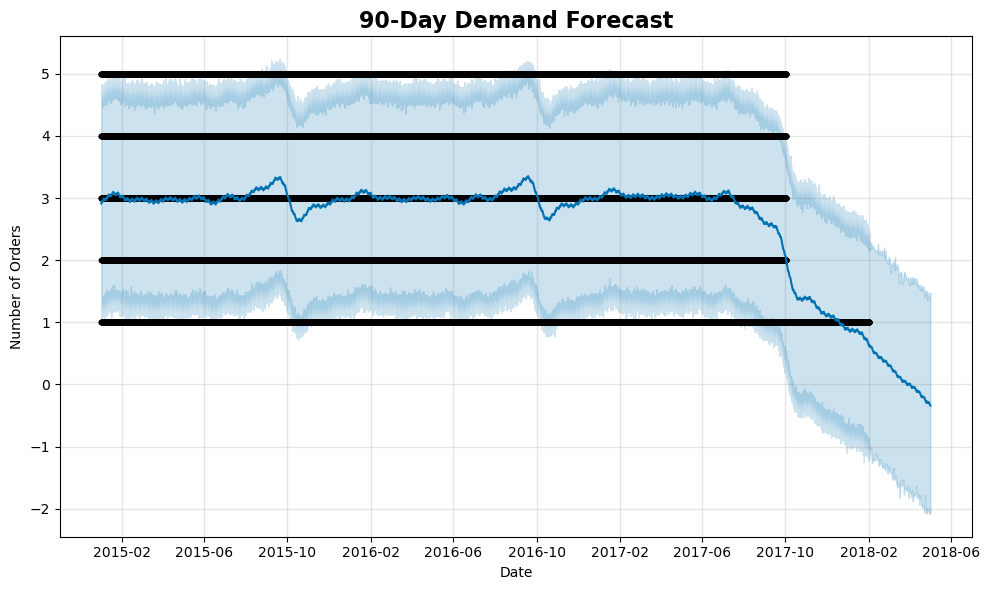

Forecast chart saved!


In [8]:
fig = model.plot(forecast)
plt.title('90-Day Demand Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('visuals/chart6_demand_forecast.png', dpi=150)
plt.show()
print("Forecast chart saved!")

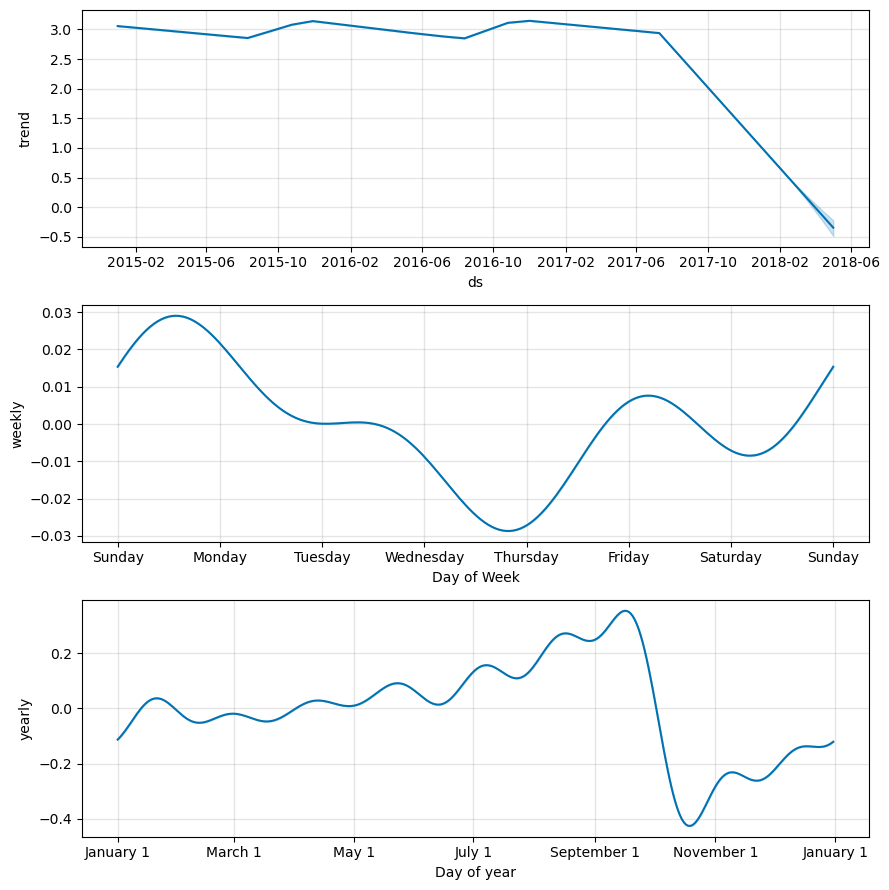

Components chart saved!


In [9]:
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig('visuals/chart7_forecast_components.png', dpi=150)
plt.show()
print("Components chart saved!")

In [10]:
future_only = forecast[forecast['ds'] > daily_orders['ds'].max()]

print("=== 90-Day Forecast Summary ===")
print(f"Average Daily Orders (predicted): {future_only['yhat'].mean():.0f}")
print(f"Max Predicted Orders in a day: {future_only['yhat'].max():.0f}")
print(f"Min Predicted Orders in a day: {future_only['yhat'].min():.0f}")
print(f"Total Predicted Orders (90 days): {future_only['yhat'].sum():.0f}")

=== 90-Day Forecast Summary ===
Average Daily Orders (predicted): 0
Max Predicted Orders in a day: 1
Min Predicted Orders in a day: -0
Total Predicted Orders (90 days): 12


In [11]:
forecast_export = future_only[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export.columns = ['Date', 'Predicted_Orders', 'Lower_Bound', 'Upper_Bound']
forecast_export['Date'] = forecast_export['Date'].dt.strftime('%Y-%m-%d')
forecast_export.to_csv('data/cleaned/demand_forecast.csv', index=False)
print("Forecast saved to data/cleaned/demand_forecast.csv")
print(forecast_export.head(10))

Forecast saved to data/cleaned/demand_forecast.csv
             Date  Predicted_Orders  Lower_Bound  Upper_Bound
65752  2018-02-01          0.631221    -1.008255     2.310516
65753  2018-02-02          0.601435    -1.117423     2.168771
65754  2018-02-03          0.606269    -1.020383     2.287894
65755  2018-02-04          0.597381    -1.269333     2.230359
65756  2018-02-05          0.559752    -1.231540     2.189689
65757  2018-02-06          0.536313    -1.221408     2.235564
65758  2018-02-07          0.502969    -1.196284     2.185453
65759  2018-02-08          0.522587    -1.228027     2.158643
65760  2018-02-09          0.497193    -1.105998     2.146377
65761  2018-02-10          0.506771    -1.095112     2.129878


In [12]:
print("Files in data/cleaned/:")
for f in os.listdir('data/cleaned/'):
    print("done", f)

print("\nFiles in visuals/:")
for f in os.listdir('visuals/'):
    print("done", f)

Files in data/cleaned/:
done demand_forecast.csv
done supply_chain_cleaned.csv

Files in visuals/:
done chart1_sales_by_category.png
done chart2_orders_by_region.png
done chart3_delivery_status.png
done chart4_monthly_sales_trend.png
done chart5_profit_vs_sales.png
done chart6_demand_forecast.png
done chart7_forecast_components.png


In [1]:
import os
import shutil

src = r'C:\Users\user\Documents\supply_chain_analysis\data\cleaned\supply_chain_cleaned.csv'
dst = r'C:\ProgramData\MySQL\MySQL Server 8.0\Uploads\supply_chain_cleaned.csv'

shutil.copy(src, dst)
print("File copied successfully!")

File copied successfully!


In [2]:
import pandas as pd
import os
os.chdir(r'C:\Users\user\Documents\supply_chain_analysis')
df = pd.read_csv('data/cleaned/supply_chain_cleaned.csv', encoding='latin-1')
print(df.columns.tolist())
print(df.shape)

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode', 'delivery_delay_days']
(180519, 51)


In [3]:
import os
os.chdir(r'C:\Users\user\Documents\supply_chain_analysis')

print("Cleaned data files:")
for f in os.listdir('data/cleaned/'):
    print(" ✅", f)

print("\nVisuals:")
for f in os.listdir('visuals/'):
    print(" ✅", f)

Cleaned data files:
 ✅ demand_forecast.csv
 ✅ supply_chain_cleaned.csv

Visuals:
 ✅ chart1_sales_by_category.png
 ✅ chart2_orders_by_region.png
 ✅ chart3_delivery_status.png
 ✅ chart4_monthly_sales_trend.png
 ✅ chart5_profit_vs_sales.png
 ✅ chart6_demand_forecast.png
 ✅ chart7_forecast_components.png
